In [159]:
import numpy as np

measurement = np.load("D:\Code\AMMH\Env\Results\RealExp_1\Realexp1_irregular\expanded_point_cloud.npy")
measurement = measurement[measurement[:, -1] > -4]
measurement = measurement[measurement[:, -1] < 4]

In [148]:
np.max(measurement[:, 0]), np.min(measurement[:, 0]), np.max(measurement[:, 1]), np.min(measurement[:, 1]), np.max(measurement[:, 2]), np.min(measurement[:, 2]), measurement.shape


(np.float64(32.8884629555066),
 np.float64(-30.34534179558494),
 np.float64(31.74089001610662),
 np.float64(-33.37498794356844),
 np.float64(3.998668363160754),
 np.float64(-3.9994361215193934),
 (29279, 3))

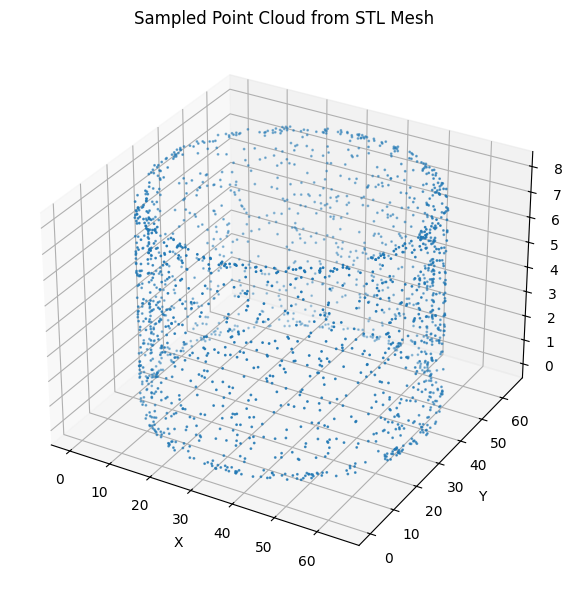

(np.float64(64.95829010009766),
 np.float64(0.041715800762176514),
 np.float64(64.99654705662589),
 np.float64(0.00349137706312972),
 np.float64(8.0),
 np.float64(0.0))

In [149]:
import trimesh
import matplotlib.pyplot as plt
mesh = trimesh.load_mesh("D:\Code\AMMH\Env\Results\STL\holes\\1.STL")
sampled_points, _ = trimesh.sample.sample_surface(mesh, 2000)

sampled_points[:, [1, 2]] = sampled_points[:, [2, 1]]
# For ellipse
# sampled_points[:, [0, 1]] = sampled_points[:, [1, 0]] 
gt_pcd = sampled_points
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(sampled_points[:, 0], sampled_points[:, 1], sampled_points[:, 2], s=1)
ax.set_title('Sampled Point Cloud from STL Mesh')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.tight_layout()
plt.show()
np.max(sampled_points[:, 0]), np.min(sampled_points[:, 0]), np.max(sampled_points[:, 1]), np.min(sampled_points[:, 1]), np.max(sampled_points[:, 2]), np.min(sampled_points[:, 2])

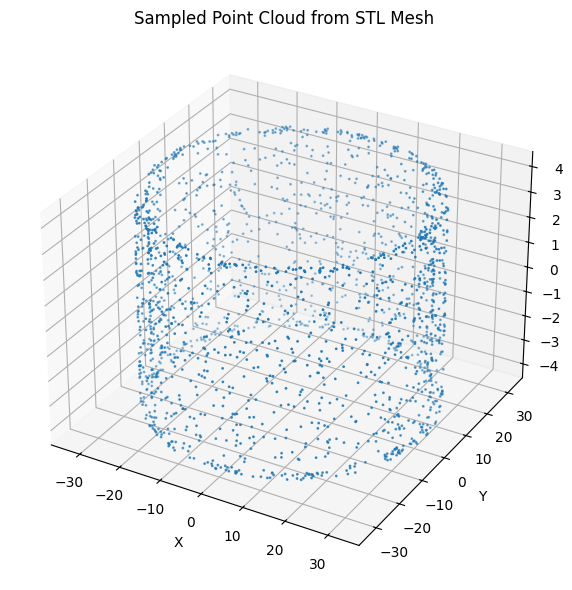

(np.float64(32.458290100097656),
 np.float64(-32.45828419923782),
 np.float64(32.496547056625886),
 np.float64(-32.49650862293687),
 np.float64(4.0),
 np.float64(-4.0))

In [150]:
# For sphere
sampled_points[:, 0] = sampled_points[:, 0] - 32.5
sampled_points[:, 1] = sampled_points[:, 1] - 32.5


# For irregular
# sampled_points[:, 0] = sampled_points[:, 0] - 50
# sampled_points[:, 1] = sampled_points[:, 1] - 31.5


sampled_points[:, 2] = sampled_points[:, 2] - 4
gt_pcd = sampled_points
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(sampled_points[:, 0], sampled_points[:, 1], sampled_points[:, 2], s=1)
ax.set_title('Sampled Point Cloud from STL Mesh')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.tight_layout()

plt.show()
np.max(sampled_points[:, 0]), np.min(sampled_points[:, 0]), np.max(sampled_points[:, 1]), np.min(sampled_points[:, 1]), np.max(sampled_points[:, 2]), np.min(sampled_points[:, 2])

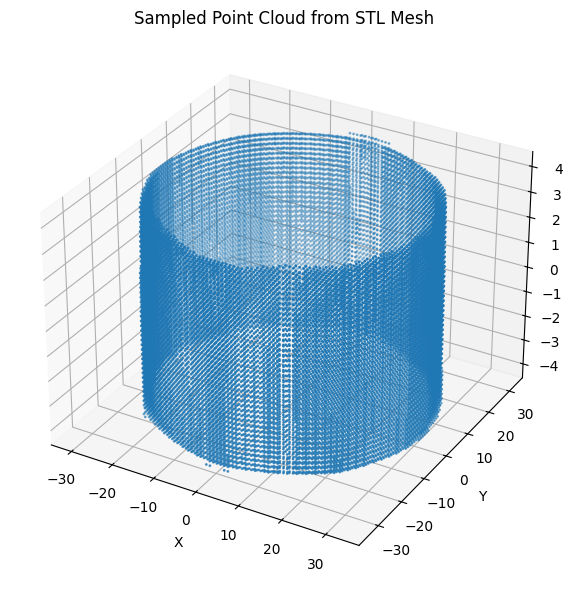

In [151]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(measurement[:, 0], measurement[:, 1], measurement[:, 2], s=1)
ax.set_title('Sampled Point Cloud from STL Mesh')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.tight_layout()
plt.show()

In [152]:
import open3d as o3d
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(sampled_points)
pcd2 = o3d.geometry.PointCloud()
pcd2.points = o3d.utility.Vector3dVector(measurement)
pcd.paint_uniform_color([0, 0, 0])
pcd2.paint_uniform_color([0, 0, 1])
# 可视化点云
o3d.visualization.draw_geometries([pcd, pcd2], window_name='Sampled STL Point Cloud')

In [153]:
import open3d as o3d
from scipy.spatial import cKDTree

def compute_chamfer_distance(pcd1_np, pcd2_np):
    tree1 = cKDTree(pcd1_np)
    tree2 = cKDTree(pcd2_np)
    dist1, _ = tree1.query(pcd2_np)
    dist2, _ = tree2.query(pcd1_np)
    chamfer_dist = np.mean(dist1 ** 2) + np.mean(dist2 ** 2)
    return chamfer_dist

In [154]:
cd = compute_chamfer_distance(measurement, gt_pcd)
print(f'Chamfer Distance between OBJ1 reconstruction and GT cylinder: {cd:.6f}')


Chamfer Distance between OBJ1 reconstruction and GT cylinder: 3.020072


In [162]:
mesh = trimesh.load_mesh("D:\Code\AMMH\Env\Results\STL\holes\\3.STL")
vertices = mesh.vertices.copy()
vertices[:, [1, 2]] = vertices[:, [2, 1]]
vertices[:, [0, 1]] = vertices[:, [1, 0]]  # Swap x and y for ellipse alignment

# For sphere
# vertices[:, 0] = vertices[:, 0] - 32.5
# vertices[:, 1] = vertices[:, 1] - 32.5


# For irregular
vertices[:, 0] -= 32.5  # x shift
vertices[:, 1] -= 22.5  # y shift


vertices[:, 2] -= 4     # z shift

# Assign back the transformed vertices to the mesh
mesh.vertices = vertices

pcd3 = o3d.geometry.PointCloud()
pcd3.points = o3d.utility.Vector3dVector(measurement)

# 采样为 2000 点
sampled_measurement = pcd3.farthest_point_down_sample(2000)
measurement_sampled_np = np.asarray(sampled_measurement.points)
closest_points, distances, _ = trimesh.proximity.closest_point(mesh, measurement_sampled_np)

rmsd = np.sqrt(np.mean(distances ** 2))
print(f"RMSD (point-to-mesh): {rmsd:.6f} mm")

RMSD (point-to-mesh): 5.167200 mm


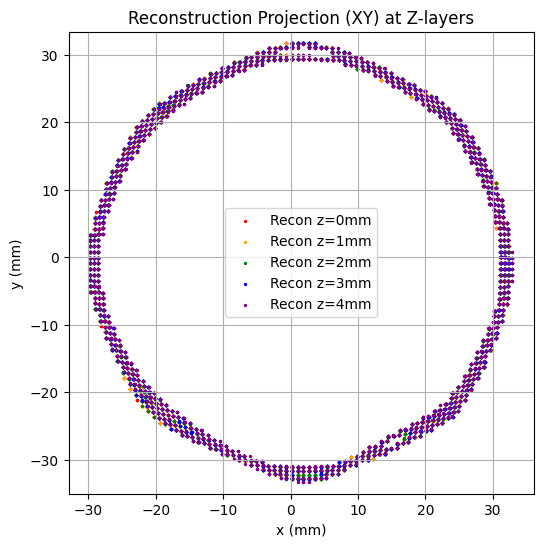

In [158]:
import matplotlib.pyplot as plt

z_layers_target = [0, 1, 2, 3, 4]
layer_thickness = 1.0
colors = ['red', 'orange', 'green', 'blue', 'purple']

plt.figure(figsize=(6, 6))
for i, z_center in enumerate(z_layers_target):
    z_min = z_center - layer_thickness / 2
    z_max = z_center + layer_thickness / 2
    recon_layer = measurement[(measurement[:, 2] >= z_min) & (measurement[:, 2] < z_max)]
    recon_xy = recon_layer[:, :2]
    plt.scatter(recon_xy[:, 0], recon_xy[:, 1], color=colors[i], s=2, label=f"Recon z={z_center}mm")

plt.title("Reconstruction Projection (XY) at Z-layers")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

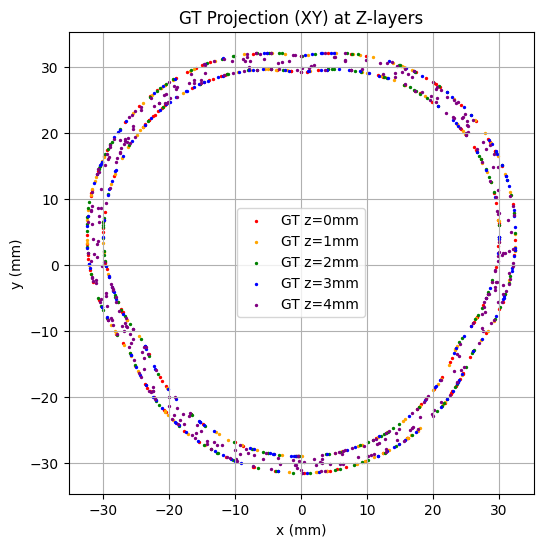

In [143]:
plt.figure(figsize=(6, 6))
for i, z_center in enumerate(z_layers_target):
    z_min = z_center - layer_thickness / 2
    z_max = z_center + layer_thickness / 2
    gt_layer = gt_pcd[(gt_pcd[:, 2] >= z_min) & (gt_pcd[:, 2] < z_max)]
    gt_xy = gt_layer[:, :2]
    plt.scatter(gt_xy[:, 0], gt_xy[:, 1], color=colors[i], s=2, label=f"GT z={z_center}mm")

plt.title("GT Projection (XY) at Z-layers")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

In [144]:
gt_pts = gt_pcd
recon_pts = measurement

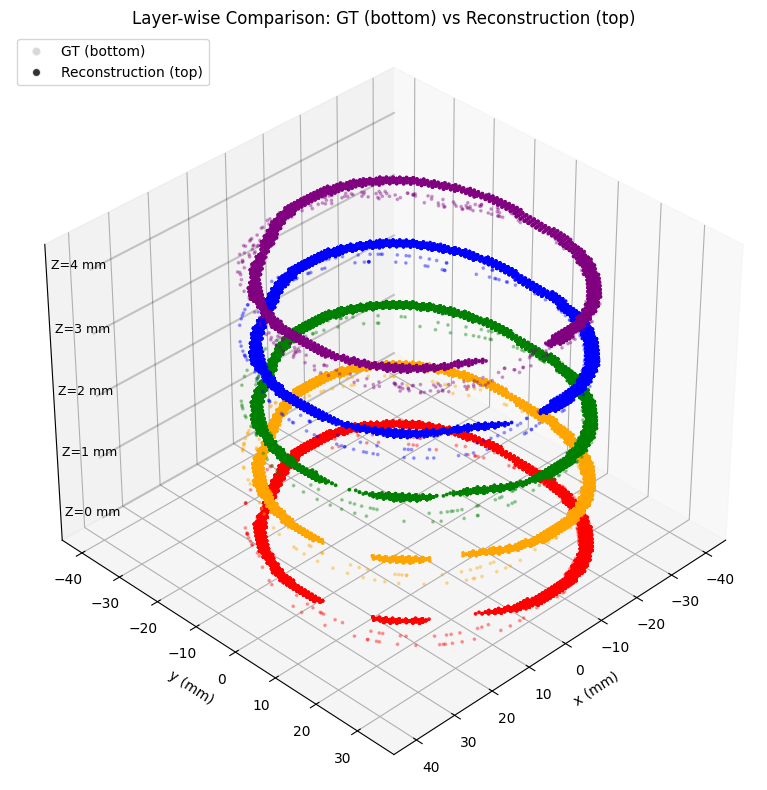

In [145]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create 3D figure
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Parameters
z_layers_target = [0, 1, 2, 3, 4]
layer_thickness = 1.0
colors = ['red', 'orange', 'green', 'blue', 'purple']
z_base = 0
z_gap = 12  # space between each layer pair
recon_offset = 2  # height difference between GT and Reconstruction within same layer

# Plot each layer pair: GT and Reconstruction
for i, z_center in enumerate(z_layers_target):
    z_min = z_center - layer_thickness / 2
    z_max = z_center + layer_thickness / 2
    color = colors[i]
    layer_z_base = z_base + i * z_gap

    # Get GT layer
    gt_layer = gt_pts[(gt_pts[:, 2] >= z_min) & (gt_pts[:, 2] < z_max)]
    if len(gt_layer) > 0:
        gt_xy = gt_layer[:, :2]
        ax.scatter(gt_xy[:, 0], gt_xy[:, 1],
                   zs=layer_z_base, zdir='z',
                   color=color, alpha=0.3, s=3,
                   label=f"GT z={z_center}mm" if i == 0 else None)

    # Get Reconstruction layer
    recon_layer = recon_pts[(recon_pts[:, 2] >= z_min) & (recon_pts[:, 2] < z_max)]
    if len(recon_layer) > 0:
        recon_xy = recon_layer[:, :2]
        ax.scatter(recon_xy[:, 0], recon_xy[:, 1],
                   zs=layer_z_base + recon_offset, zdir='z',
                   color=color, alpha=0.9, s=3,
                   label=f"Reconstruction z={z_center}mm" if i == 0 else None)

    # Add separator text
    ax.text(x=45, y=-45, z=layer_z_base + 1, s=f"Z={z_center} mm", color='black', fontsize=9)
    ax.plot([-40, 40], [-40, -40], zs=layer_z_base + 1, color='black', alpha=0.1)
    ax.plot([-40, 40], [-40, -40], zs=layer_z_base + recon_offset - 1, color='black', alpha=0.1)

# Add legend manually
custom_lines = [
    plt.Line2D([0], [0], marker='o', color='w', label='GT (bottom)', markerfacecolor='gray', markersize=6, alpha=0.3),
    plt.Line2D([0], [0], marker='o', color='w', label='Reconstruction (top)', markerfacecolor='black', markersize=6, alpha=0.8)
]
ax.legend(handles=custom_lines, loc='upper left')

# Plot settings
ax.set_title("Layer-wise Comparison: GT (bottom) vs Reconstruction (top)")
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_zlabel("")
ax.set_zticks([])
ax.view_init(elev=35, azim=45)
plt.tight_layout()
plt.show()
